This notebook covers the core concepts of Seaborn, a powerful Python data visualization library built on Matplotlib. We'll explore various plot types, styling options, and apply them in a basic Exploratory Data Analysis (EDA) workflow. This is designed to be an interactive learning experience, so feel free to run and modify the code cells!

## Phase 1 — Core Seaborn

### We'll Cover:

*   Importing Seaborn and Matplotlib
*   Built-in datasets for learning
*   `scatterplot()`: Relationships, correlations, trends
*   `lineplot()`: Trends, progression, time-series data
*   `barplot()`: Averages, comparisons
*   `countplot()`: Category frequencies, distributions
*   `histplot()` / `displot()`: Distribution analysis, density
*   `boxplot()`: Outlier detection, spread, quartiles
*   `violinplot()`: Distribution shape, density, spread
*   `heatmap()`: Correlations, matrix visualization
*   `pairplot()`: Automatic relationships and distributions
*   Styling: Themes, figure size, color palettes
*   Real EDA Workflow: Practical application

**This is the MOST important 80% for getting started.**

---

## 1. Import Seaborn and Matplotlib

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Will be useful for data handling

## 2. Built-in Datasets

Seaborn provides several sample datasets, which are *very* useful for learning and practicing visualization techniques without needing to find and clean data.

### See Available Datasets

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


### Load Dataset: `tips`

We'll use the `tips` dataset, a very famous dataset containing information about restaurant bills, tips, gender of the payer, smoking status, day of the week, and time of day.

In [3]:
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### ALWAYS Inspect Dataset First

Just like with any Pandas DataFrame, it's crucial to inspect your data to understand its structure, data types, and identify any missing values. This workflow is exactly like standard Pandas data analysis.

In [4]:
print("\n--- Dataset Info ---")
tips.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
print("\n--- Descriptive Statistics ---")
tips.describe()


--- Descriptive Statistics ---


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [6]:
print("\n--- Missing Values ---")
tips.isnull().sum()


--- Missing Values ---


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


## 3. `scatterplot()`

Used for:
*   Visualizing relationships between two numerical variables.
*   Identifying correlations.
*   Observing trends.

### Example: Total Bill vs. Tip

Question being answered: “Does a larger bill mean a larger tip?”

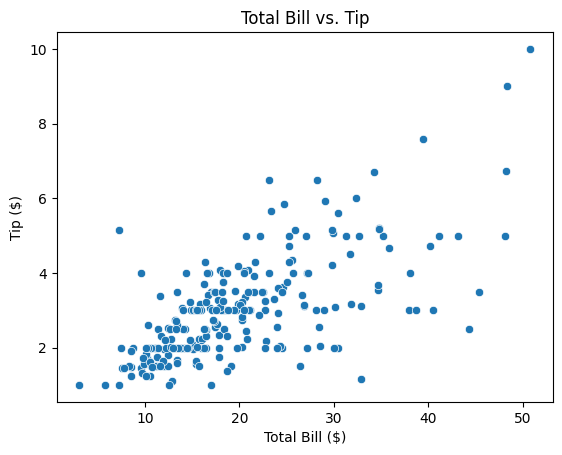

In [7]:
sns.scatterplot(
    x="total_bill",
    y="tip",
    data=tips
)
plt.title("Total Bill vs. Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

### Add Hue (VERY IMPORTANT)

Adding `hue` allows you to color points based on a categorical variable, revealing additional patterns or distinctions within the data. Seaborn automatically groups categories visually, making it extremely powerful in EDA.

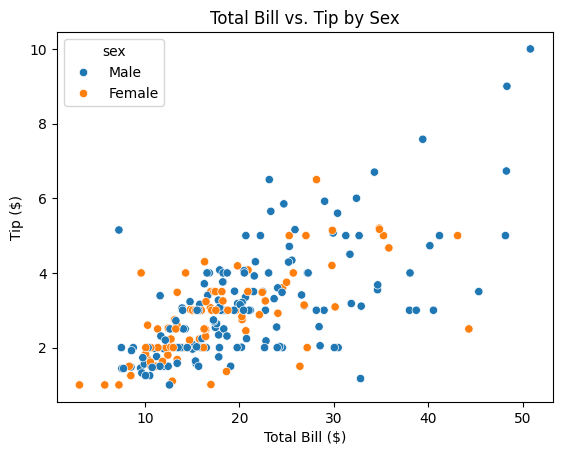

In [8]:
sns.scatterplot(
    x="total_bill",
    y="tip",
    hue="sex",
    data=tips
)
plt.title("Total Bill vs. Tip by Sex")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

## 4. `lineplot()`

Used for:
*   Displaying trends over a continuous variable (often time).
*   Showing progression or changes.
*   Ideal for time-series style data.

### Example: Total Bill by Size

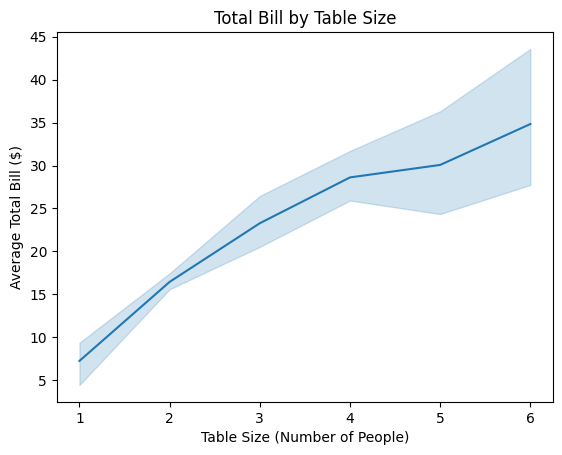

In [9]:
sns.lineplot(
    x="size",
    y="total_bill",
    data=tips
)
plt.title("Total Bill by Table Size")
plt.xlabel("Table Size (Number of People)")
plt.ylabel("Average Total Bill ($)")
plt.show()

## 5. `barplot()`

**SUPER IMPORTANT.**

Used for:
*   Comparing numerical values across different categories.
*   Seaborn *automatically computes the average* of the numerical variable for each category, which is a **VERY IMPORTANT difference from Matplotlib's `bar` plot**.

### Example: Average Total Bill by Day

What does this show? The average total bill for each day of the week.

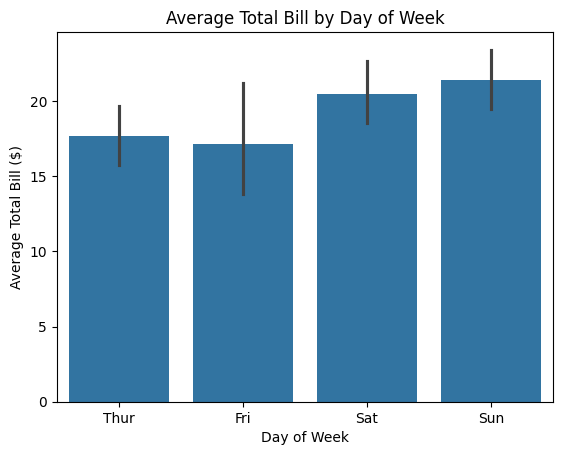

In [10]:
sns.barplot(
    x="day",
    y="total_bill",
    data=tips
)
plt.title("Average Total Bill by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Total Bill ($)")
plt.show()

### Add Hue

Again, adding `hue` helps to break down the averages by another categorical variable, like gender in this case.

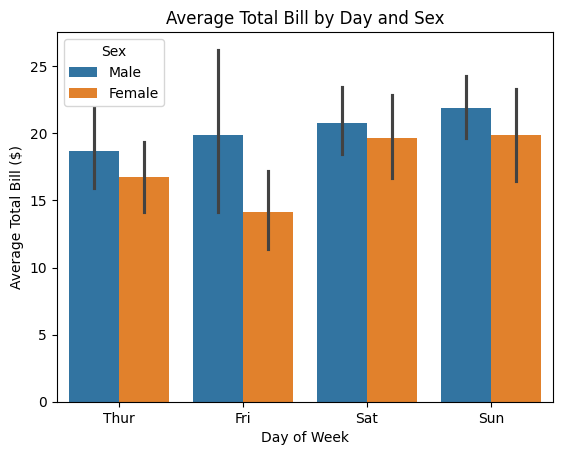

In [11]:
sns.barplot(
    x="day",
    y="total_bill",
    hue="sex",
    data=tips
)
plt.title("Average Total Bill by Day and Sex")
plt.xlabel("Day of Week")
plt.ylabel("Average Total Bill ($)")
plt.legend(title="Sex")
plt.show()

## 6. `countplot()`

**EXTREMELY COMMON.**

Used for:
*   Showing the counts of observations in each category.
*   Similar to a bar plot, but the y-axis implicitly represents the count of records.

### Example: Number of Observations per Day

Shows how many entries (or transactions) exist for each day of the week.

### Real Usage

*   Gender distribution
*   Fraud counts
*   Category frequencies
*   Class imbalance in Machine Learning (VERY important).

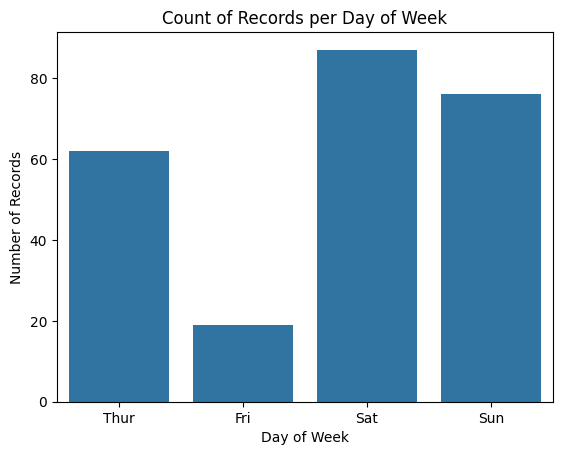

In [12]:
sns.countplot(
    x="day",
    data=tips
)
plt.title("Count of Records per Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Records")
plt.show()

## 7. `histplot()` / `displot()`

Used for:
*   Distribution analysis of a single numerical variable.
*   Understanding the frequency of values within certain bins.
*   **SUPER IMPORTANT in Machine Learning** for feature analysis.

### Histogram

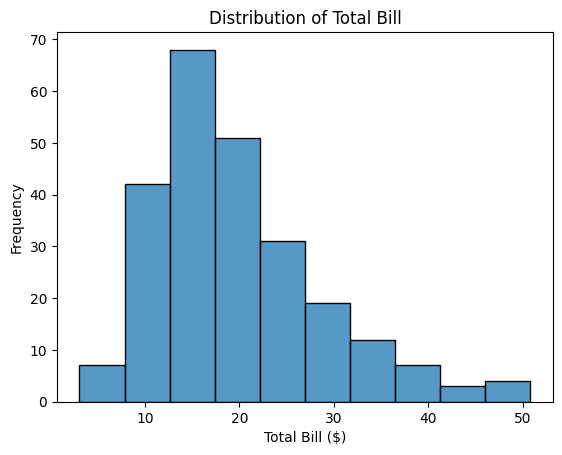

In [13]:
sns.histplot(
    tips["total_bill"],
    bins=10 # You can adjust the number of bins
)
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()

### KDE Curve (Kernel Density Estimate)

Adding `kde=True` overlays a smooth curve representing the probability density estimate of the distribution. This is very important for understanding:

*   Normal distribution intuition
*   Shape and modality of the distribution

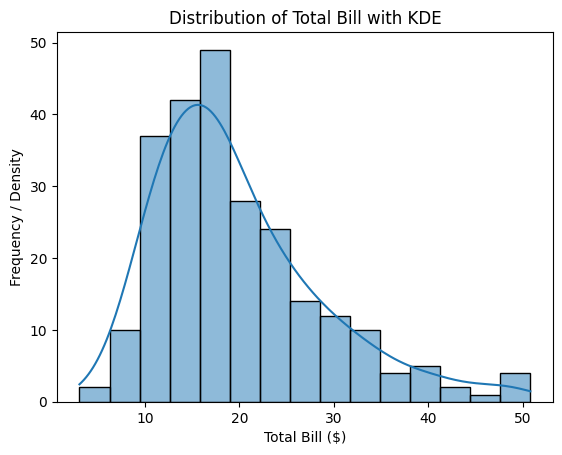

In [14]:
sns.histplot(
    tips["total_bill"],
    kde=True,
    bins=15 # Adjust bins for better visualization
)
plt.title("Distribution of Total Bill with KDE")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency / Density")
plt.show()

## 8. `boxplot()`

**ONE OF THE MOST IMPORTANT PLOTS IN DATA SCIENCE.**

Used for:
*   Identifying outliers.
*   Analyzing the spread and skewness of data.
*   Visualizing quartiles and the median.

### Example: Total Bill Distribution by Day

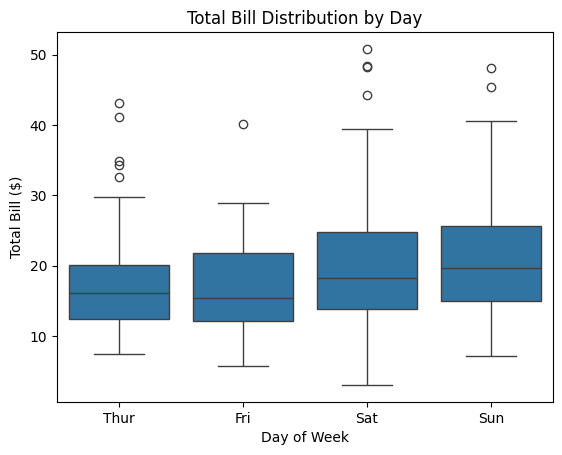

In [15]:
sns.boxplot(
    x="day",
    y="total_bill",
    data=tips
)
plt.title("Total Bill Distribution by Day")
plt.xlabel("Day of Week")
plt.ylabel("Total Bill ($)")
plt.show()

### Understanding a Boxplot

A boxplot shows:
*   The **median** (the line inside the box).
*   The **first quartile (Q1)** and **third quartile (Q3)** (the edges of the box).
*   The **Interquartile Range (IQR)**: Q3 - Q1 (the length of the box).
*   **Whiskers**: Extend to the most extreme data points within 1.5 * IQR from Q1 and Q3.
*   **Outliers**: Data points beyond the whiskers (shown as individual dots).

This is heavily used in EDA, especially for **outlier detection**, which is VERY important in ML preprocessing.

## 9. `violinplot()`

Used for:
*   Combining a boxplot with a kernel density estimate.
*   Shows both the central tendency (like a boxplot) and the distribution shape (like a KDE).
*   More advanced statistical visualization.

### Example: Total Bill Distribution by Day

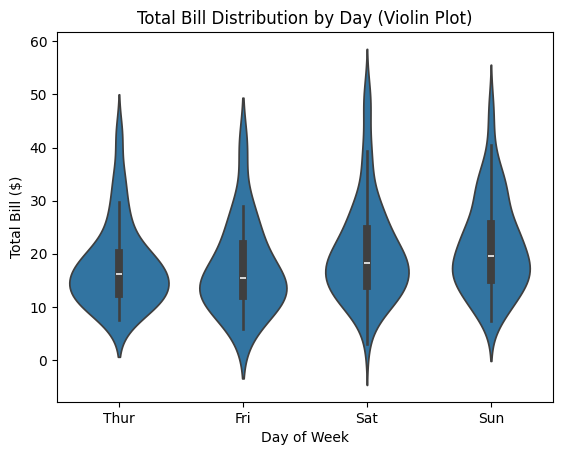

In [16]:
sns.violinplot(
    x="day",
    y="total_bill",
    data=tips
)
plt.title("Total Bill Distribution by Day (Violin Plot)")
plt.xlabel("Day of Week")
plt.ylabel("Total Bill ($)")
plt.show()

## 10. `heatmap()`

**MOST IMPORTANT Seaborn plot for ML beginners, especially for feature selection.**

Used for:
*   Visualizing correlation matrices.
*   Displaying relationships between many variables simultaneously.
*   Matrix visualization.

### Correlation Matrix

First, we need to calculate the pairwise correlation between numerical columns in our dataset.

In [17]:
corr = tips.corr(numeric_only=True)
print(corr)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


### Heatmap Visualization

Now, we'll visualize this correlation matrix using a heatmap. The `annot=True` argument displays the correlation values on the map, and `cmap="coolwarm"` sets the color scheme (blue for negative, red for positive, white for neutral).

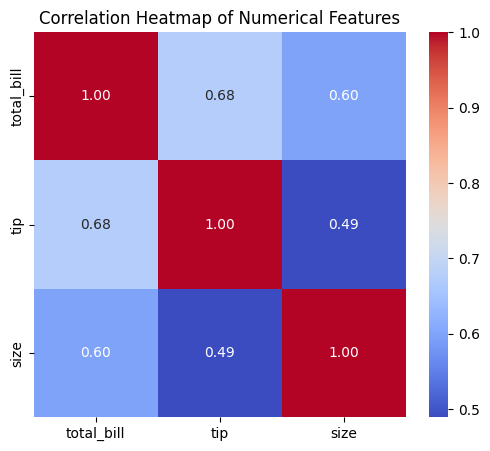

In [18]:
plt.figure(figsize=(6, 5)) # Adjust figure size for better readability
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f" # Format annotations to two decimal places
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Why Heatmaps Matter

In Machine Learning, heatmaps are crucial for:
*   Checking which features are strongly related to each other (multicollinearity).
*   Identifying patterns and relationships that might influence model performance.

**Understanding Correlation:**
*   Values close to **1**: Strong positive relation (as one increases, the other tends to increase).
*   Values close to **-1**: Strong negative relation (as one increases, the other tends to decrease).
*   Values near **0**: Weak or no linear relation.

## 11. `pairplot()`

**MAGICAL for beginners!**

Used for:
*   Creating scatterplots for all pairwise relationships between numerical columns.
*   Creating histograms or KDEs for the diagonal (distribution of individual numerical columns).

### Example: Pairplot of `tips` dataset

In ONE line of code, you get:
*   Relationships between numerical variables.
*   Distributions of individual numerical variables.
*   Overall trends.

Very common in Kaggle notebooks and initial EDA.

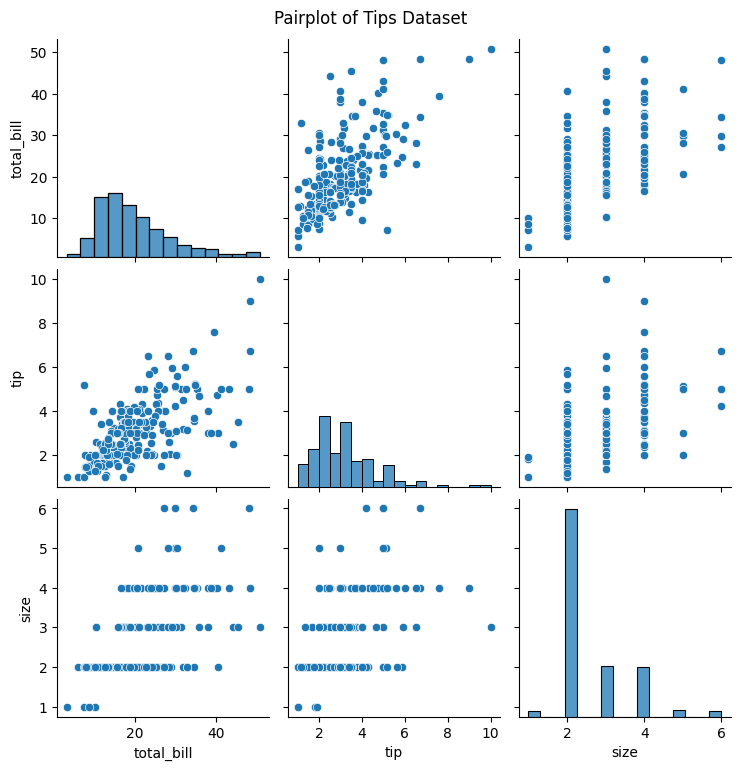

In [19]:
sns.pairplot(tips)
plt.suptitle("Pairplot of Tips Dataset", y=1.02) # Add title above plots
plt.show()

### Add Hue to `pairplot()`

Adding `hue` to a `pairplot()` is incredibly powerful, as it allows you to visualize these relationships and distributions broken down by a categorical variable.

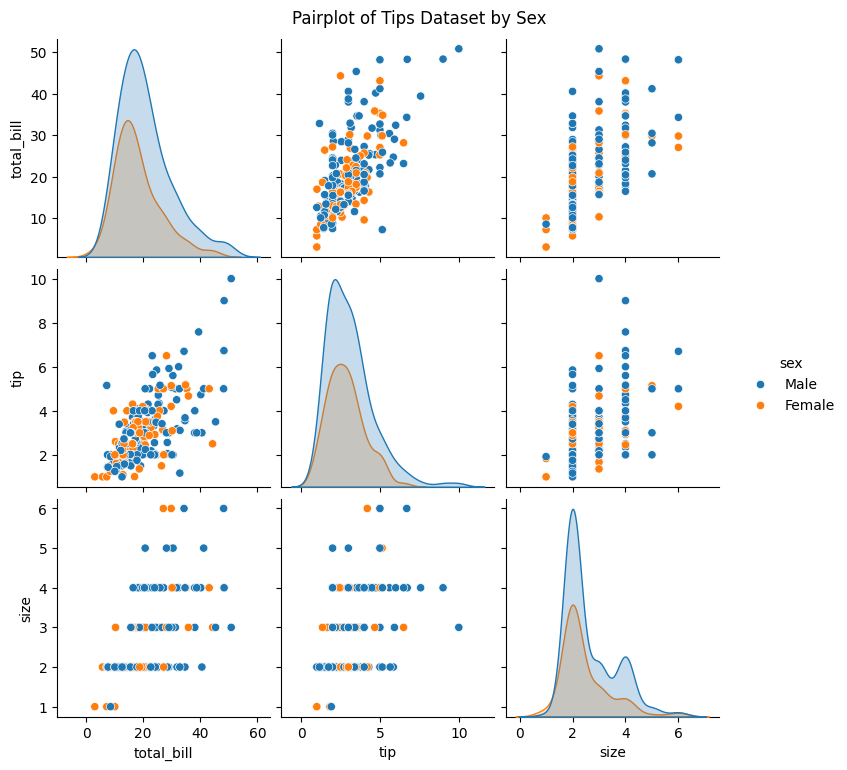

In [20]:
sns.pairplot(
    tips,
    hue="sex"
)
plt.suptitle("Pairplot of Tips Dataset by Sex", y=1.02) # Add title above plots
plt.show()

## 12. Styling

Seaborn simplifies styling your plots to make them more aesthetically pleasing and readable.

### Themes (`set_style()`)

Seaborn offers several built-in themes:
*   `darkgrid` (default)
*   `whitegrid`
*   `dark`
*   `white`
*   `ticks`

Let's set a style and see how it affects subsequent plots.

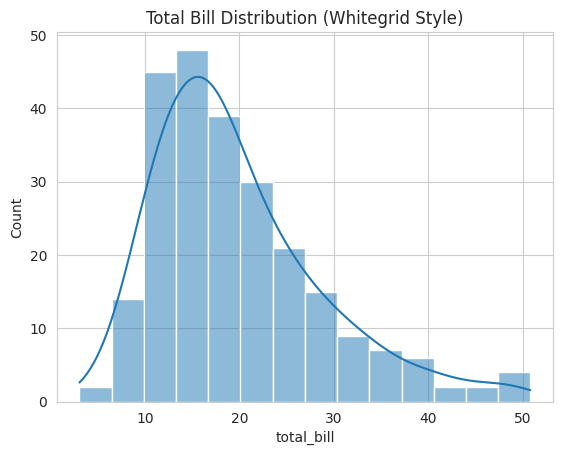

In [21]:
sns.set_style("whitegrid")

# Example plot with new style
sns.histplot(tips["total_bill"], kde=True)
plt.title("Total Bill Distribution (Whitegrid Style)")
plt.show()

### Figure Size (`plt.figure(figsize=(width, height))`)

Figure size is still controlled by Matplotlib functions.

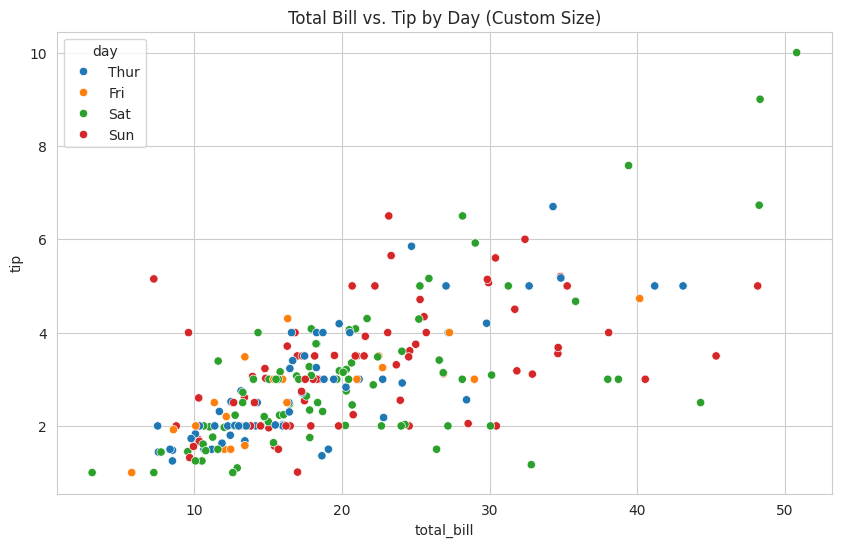

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="total_bill",
    y="tip",
    hue="day",
    data=tips
)
plt.title("Total Bill vs. Tip by Day (Custom Size)")
plt.show()

### Color Palettes (`set_palette()`)

Seaborn has many color palettes. `set_palette()` changes the default colors for all plots that follow. You can also pass palettes directly to `palette` argument in most plotting functions.

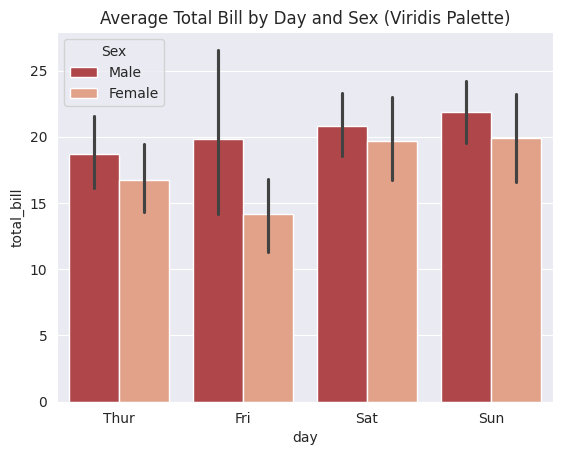

In [31]:
sns.set_palette("RdBu") # Try 'deep', 'muted', 'pastel', 'Set2', 'RdBu',viridis etc.

sns.barplot(
    x="day",
    y="total_bill",
    hue="sex",
    data=tips
)
plt.title("Average Total Bill by Day and Sex (Viridis Palette)")
plt.legend(title="Sex")
plt.show()

# Reset to default for consistency in later plots if desired
sns.set_style("darkgrid")
sns.set_palette("deep")

## 13. Real EDA Workflow

This section demonstrates a typical initial Exploratory Data Analysis (EDA) workflow using Seaborn and Pandas. This is what real analysts often do to get a first understanding of a new dataset.

1.  **Load Data**: Load the dataset.
2.  **Inspect Data**: Check structure, types, and missing values.
3.  **Visualize Overview**: Use `pairplot` for a quick look at distributions and relationships.
4.  **Analyze Correlations**: Use `heatmap` for numerical feature relationships.

In [32]:
# 1. Load Data (using our 'tips' dataset again for consistency)
df = sns.load_dataset("tips")
print("### 1. Data Head ###")
print(df.head())

### 1. Data Head ###
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [33]:
print("\n### 2. Data Info ###")
df.info()


### 2. Data Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [34]:
print("\n### 2. Data Describe ###")
print(df.describe())


### 2. Data Describe ###
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [35]:
print("\n### 2. Missing Values ###")
print(df.isnull().sum())


### 2. Missing Values ###
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64



### 3. Pairplot Visualization ###


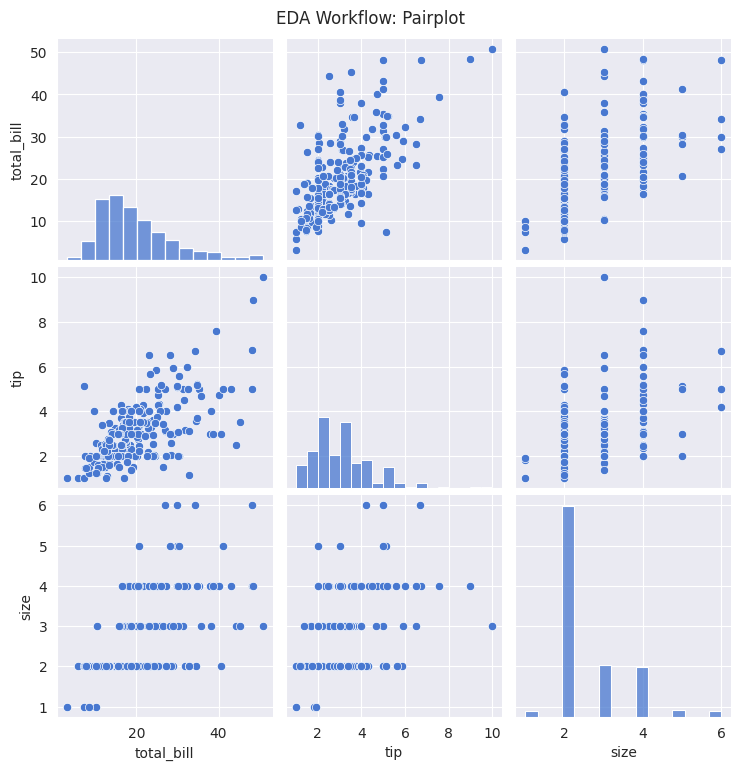

In [36]:
# 3. Visualize Overview with Pairplot
print("\n### 3. Pairplot Visualization ###")
sns.pairplot(df)
plt.suptitle("EDA Workflow: Pairplot", y=1.02)
plt.show()


### 4. Correlation Heatmap ###


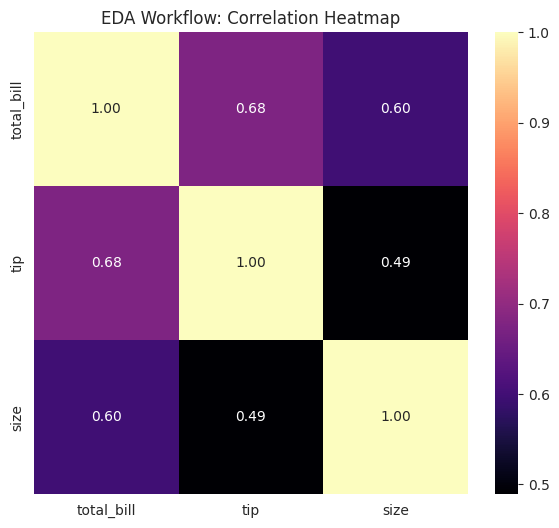

In [37]:
# 4. Analyze Correlations with Heatmap
print("\n### 4. Correlation Heatmap ###")
corr_eda = df.corr(numeric_only=True)
plt.figure(figsize=(7, 6))
sns.heatmap(corr_eda, annot=True, cmap="magma", fmt=".2f")
plt.title("EDA Workflow: Correlation Heatmap")
plt.show()

## Most Important Seaborn Plots For You

Master these first to gain a strong foundation in data visualization:

| Plot        | Usage                                     |
| :---------- | :---------------------------------------- |
| `scatterplot` | Relationships, correlations, trends       |
| `histplot`    | Distributions, frequency analysis         |
| `boxplot`     | Outliers, spread, quartiles               |
| `heatmap`     | Correlations, relationships between many  |
| `countplot`   | Category counts, distribution of categories |
| `pairplot`    | Automatic EDA, quick overview             |

If your understanding of these plots is strong, you are already at a beginner-intermediate visualization level!

---

## Beginner-Intermediate Assignment: Practice Time!

It's time to solidify your knowledge. Complete the following tasks using the `tips` dataset. Run each code block and observe the output.

### Task 1: Load and Inspect Data

*   Load the `tips` dataset.
*   Show the first 5 rows (`.head()`).
*   Display information about the DataFrame (`.info()`).
*   Show descriptive statistics (`.describe()`).
*   Check for any missing values (`.isnull().sum()`).

In [38]:
# Task 1 Solution
print("--- Task 1: Load and Inspect Data ---")

# Load the dataset
tips_assignment = sns.load_dataset("tips")

# Show head
print("\nFirst 5 rows:")
print(tips_assignment.head())

# Info
print("\nDataFrame Info:")
tips_assignment.info()

# Describe
print("\nDescriptive Statistics:")
print(tips_assignment.describe())

# Missing values
print("\nMissing Values:")
print(tips_assignment.isnull().sum())

--- Task 1: Load and Inspect Data ---

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Descriptive Statistics:
       total_bill         tip       

### Task 2: Create Relational Plots

*   Create a `scatterplot` showing `total_bill` vs. `tip`, with `smoker` as `hue`.
*   Create a `lineplot` showing the average `total_bill` by `time` (Lunch/Dinner).
*   Create a `barplot` showing the average `tip` by `day`, with `sex` as `hue`.


--- Task 2: Create Relational Plots ---


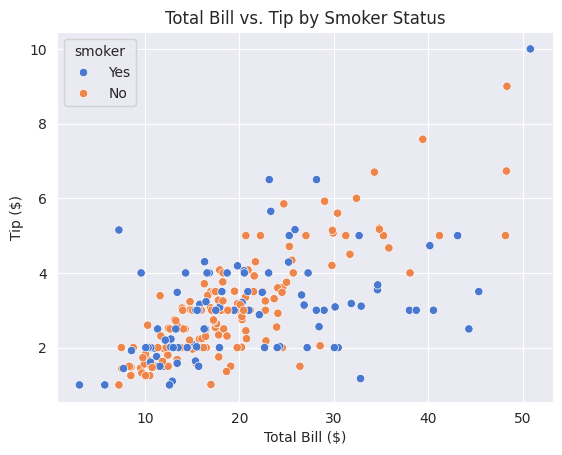

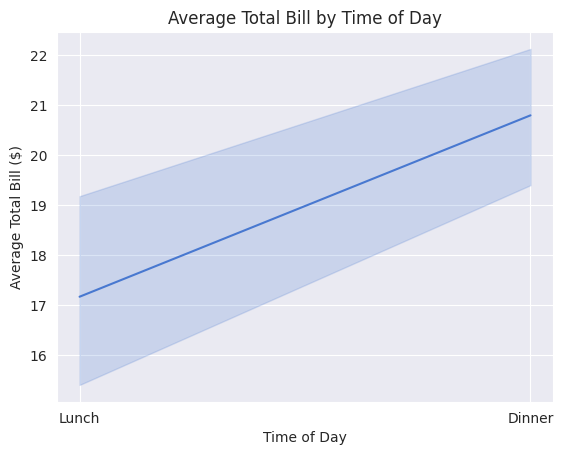

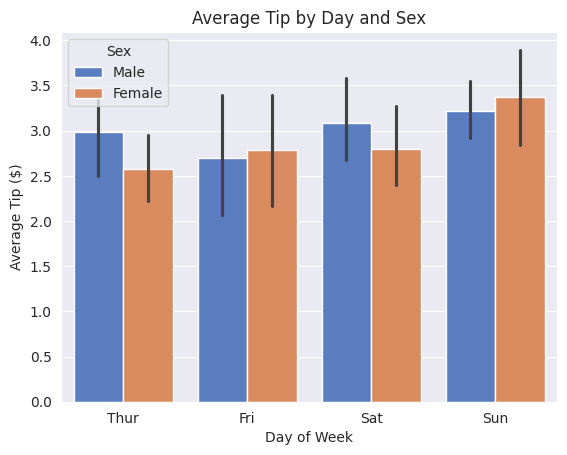

In [39]:
# Task 2 Solution
print("\n--- Task 2: Create Relational Plots ---")

# Scatterplot: total_bill vs. tip with smoker hue
sns.scatterplot(
    x="total_bill",
    y="tip",
    hue="smoker",
    data=tips_assignment
)
plt.title("Total Bill vs. Tip by Smoker Status")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# Lineplot: average total_bill by time
sns.lineplot(
    x="time",
    y="total_bill",
    data=tips_assignment
)
plt.title("Average Total Bill by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Total Bill ($)")
plt.show()

# Barplot: average tip by day with sex hue
sns.barplot(
    x="day",
    y="tip",
    hue="sex",
    data=tips_assignment
)
plt.title("Average Tip by Day and Sex")
plt.xlabel("Day of Week")
plt.ylabel("Average Tip ($)")
plt.legend(title="Sex")
plt.show()

### Task 3: Create Distribution and Statistical Plots

*   Create a `histplot` for `tip` with `kde=True`.
*   Create a `boxplot` for `total_bill` by `time`.
*   Create a `violinplot` for `tip` by `day`.


--- Task 3: Create Distribution and Statistical Plots ---


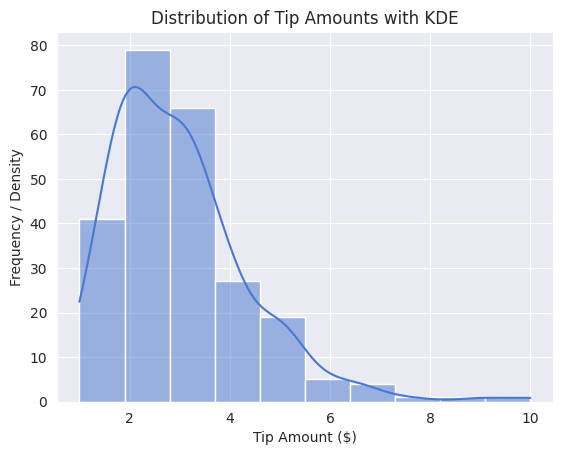

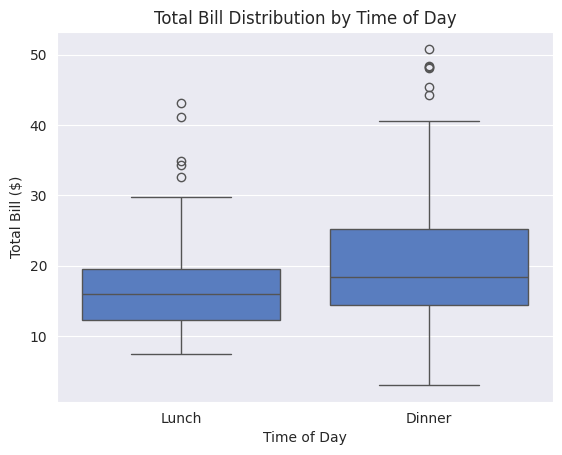

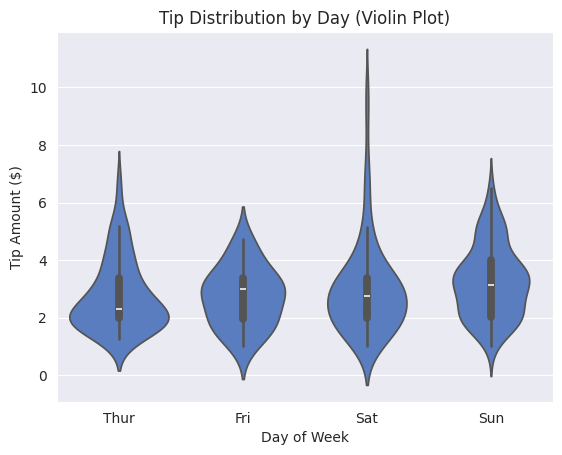

In [40]:
# Task 3 Solution
print("\n--- Task 3: Create Distribution and Statistical Plots ---")

# Histplot for tip with KDE
sns.histplot(
    tips_assignment["tip"],
    kde=True,
    bins=10
)
plt.title("Distribution of Tip Amounts with KDE")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency / Density")
plt.show()

# Boxplot for total_bill by time
sns.boxplot(
    x="time",
    y="total_bill",
    data=tips_assignment
)
plt.title("Total Bill Distribution by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Bill ($)")
plt.show()

# Violinplot for tip by day
sns.violinplot(
    x="day",
    y="tip",
    data=tips_assignment
)
plt.title("Tip Distribution by Day (Violin Plot)")
plt.xlabel("Day of Week")
plt.ylabel("Tip Amount ($)")
plt.show()

### Task 4: Create Correlation Heatmap

*   Calculate the correlation matrix for the numerical columns in the `tips` dataset.
*   Display it as a `heatmap` with annotations and a suitable colormap.


--- Task 4: Create Correlation Heatmap ---
Correlation Matrix:
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


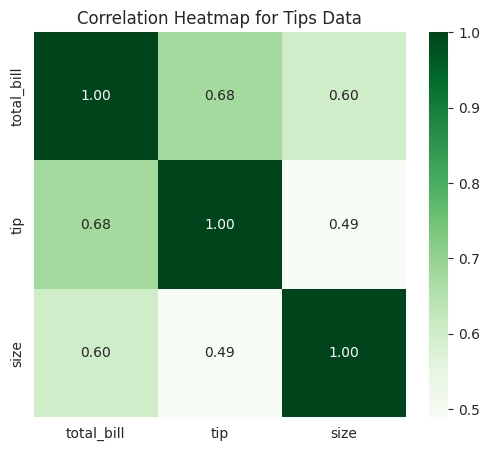

In [41]:
# Task 4 Solution
print("\n--- Task 4: Create Correlation Heatmap ---")

# Calculate correlation matrix
corr_assignment = tips_assignment.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr_assignment)

# Display heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_assignment,
    annot=True,
    cmap="Greens", # Changed colormap for variety
    fmt=".2f"
)
plt.title("Correlation Heatmap for Tips Data")
plt.show()

### Task 5: Create Pairplot with Hue

*   Create a `pairplot` for the `tips` dataset, using `time` (Lunch/Dinner) as the `hue` variable.


--- Task 5: Create Pairplot with Hue ---


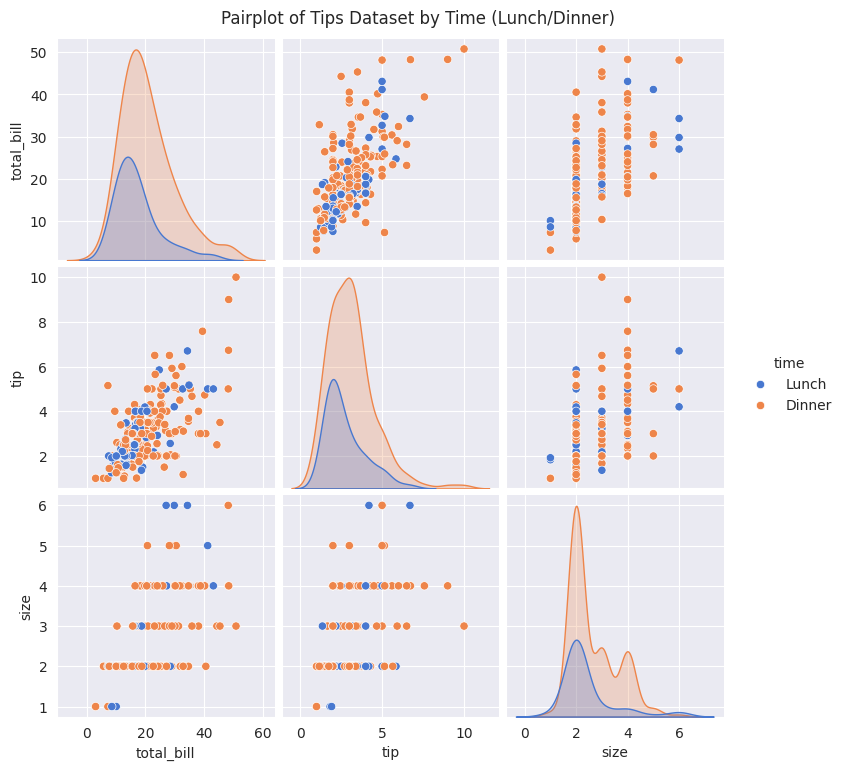

In [42]:
# Task 5 Solution
print("\n--- Task 5: Create Pairplot with Hue ---")

# Pairplot with 'time' as hue
sns.pairplot(
    tips_assignment,
    hue="time"
)
plt.suptitle("Pairplot of Tips Dataset by Time (Lunch/Dinner)", y=1.02)
plt.show()

---

## Conclusion

You've now covered the most important core Seaborn plots and applied them in various scenarios, including a basic EDA workflow and a practice assignment. Continue experimenting with different datasets and plot customizations to further enhance your visualization skills!